In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded")

All libraries loaded


### Load & First Look

In [46]:
df = pd.read_csv("/content/Student_Performance.csv")

print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
df.describe()

Shape: (10000, 6)

Data Types:
 Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities           object
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object

Missing Values:
 Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


### Exploratory Data Analysis : Distributions

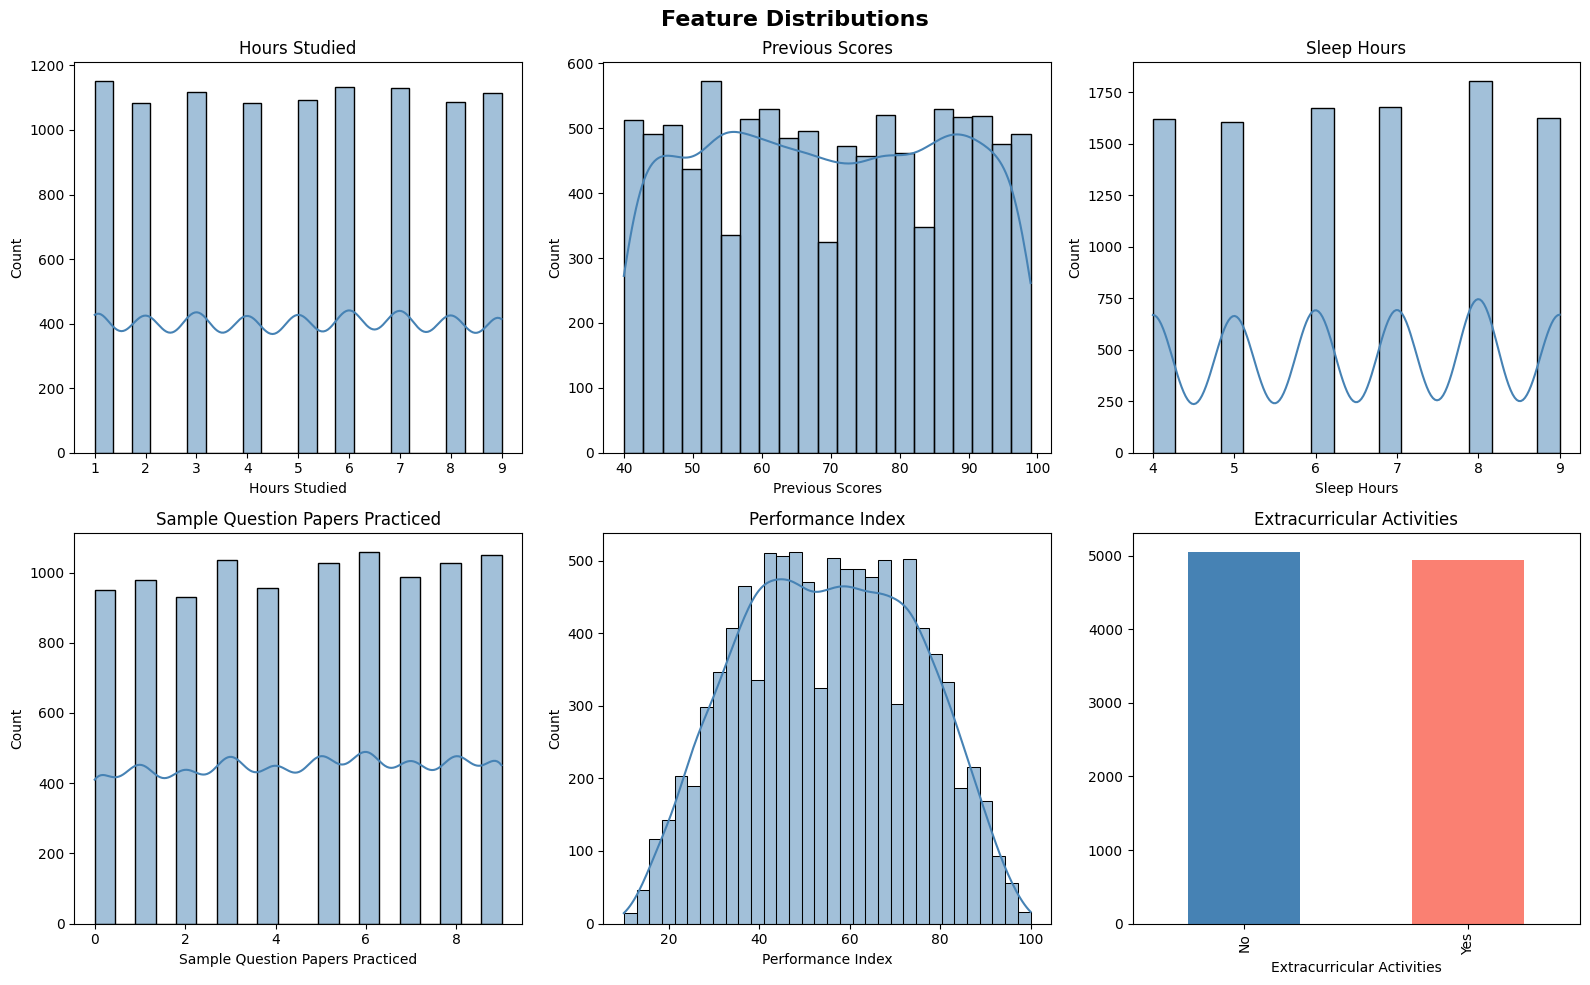

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Feature Distributions", fontsize=16, fontweight='bold')

numeric_cols = ['Hours Studied', 'Previous Scores', 'Sleep Hours',
                'Sample Question Papers Practiced', 'Performance Index']

for i, col in enumerate(numeric_cols):
    ax = axes[i // 3][i % 3]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue')
    ax.set_title(col)

axes[1][2].set_title("Extracurricular Activities")
df['Extracurricular Activities'].value_counts().plot(
    kind='bar', ax=axes[1][2], color=['steelblue', 'salmon']
)

plt.tight_layout()
plt.savefig("distributions.png", dpi=150)
plt.show()

### EDA: Correlation Heatmap

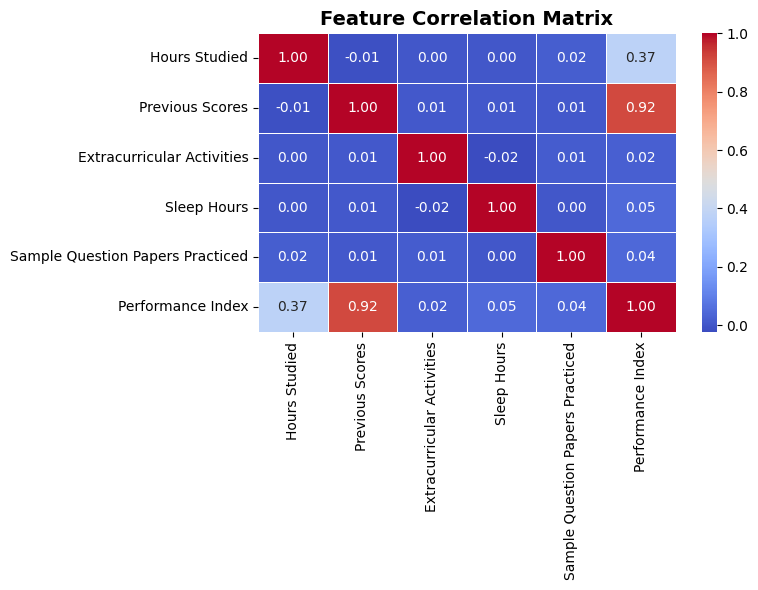

In [48]:
df_corr = df.copy()
df_corr['Extracurricular Activities'] = df_corr['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

### Key Findings:
- **Previous Scores** is by far the dominant predictor (0.92) —
  a student's past performance is the strongest indicator of future results
- **Hours Studied** has a meaningful moderate effect (0.37) —
  effort matters but doesn't override prior knowledge
- **Sleep, Papers Practiced, Extracurricular** have near-zero correlation —
  they are kept in the model but are unlikely to move the needle significantly
- All features are **independent of each other** (no multicollinearity) —
  this is ideal for linear regression

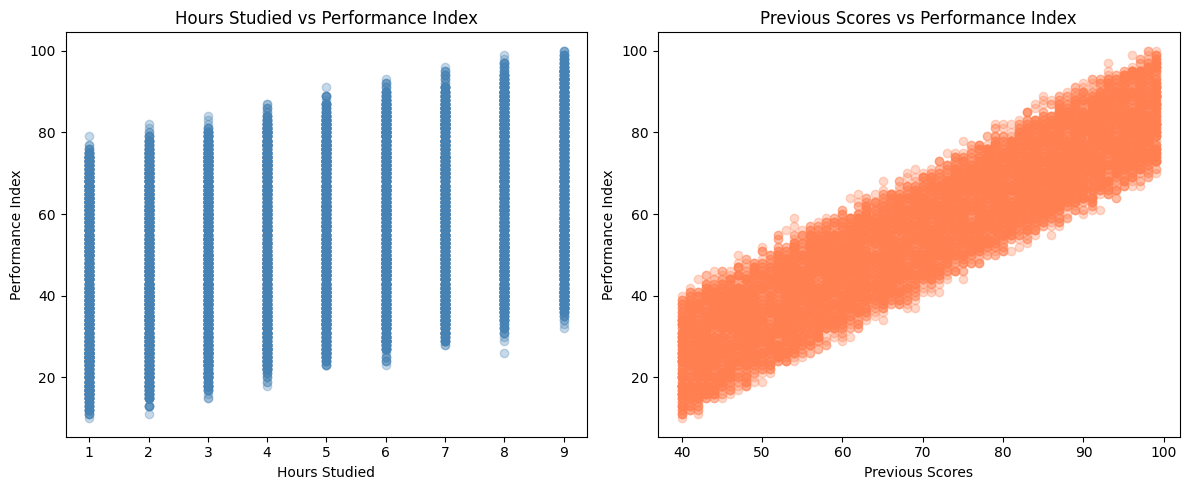

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['Hours Studied'], df['Performance Index'], alpha=0.3, color='steelblue')
axes[0].set_xlabel('Hours Studied')
axes[0].set_ylabel('Performance Index')
axes[0].set_title('Hours Studied vs Performance Index')

axes[1].scatter(df['Previous Scores'], df['Performance Index'], alpha=0.3, color='coral')
axes[1].set_xlabel('Previous Scores')
axes[1].set_ylabel('Performance Index')
axes[1].set_title('Previous Scores vs Performance Index')

plt.tight_layout()
plt.savefig("scatter_vs_target.png", dpi=150)
plt.show()

### Feature Importance via Variance

In [50]:
print("Feature Variance Analysis:")
print("(Low variance = less informative feature)\n")
print(df_corr.var().sort_values(ascending=False))

Feature Variance Analysis:
(Low variance = less informative feature)

Performance Index                   369.122377
Previous Scores                     300.784930
Sample Question Papers Practiced      8.221683
Hours Studied                         6.704520
Sleep Hours                           2.875951
Extracurricular Activities            0.249998
dtype: float64


In [51]:
print("Correlation with Target (Performance Index):\n")
correlations = df_corr.corr()['Performance Index'].drop('Performance Index')
correlations = correlations.abs().sort_values(ascending=False)
print(correlations)

print("\n Feature Engineering Decisions:")
print("=" * 50)

threshold = 0.01  # minimum correlation to keep

for feature, corr in correlations.items():
    if corr >= threshold:
        print(f"  KEEP   | {feature:40s} | correlation: {corr:.4f}")
    else:
        print(f"  DROP   | {feature:40s} | correlation: {corr:.4f}")

print("\n Final Decision: Keep ALL features")
print("   Reasoning: No feature falls below threshold (0.01).")
print("   Even weak features add marginal signal with no cost")
print("   given the dataset size (10,000 rows).")

Correlation with Target (Performance Index):

Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Extracurricular Activities          0.024525
Name: Performance Index, dtype: float64

 Feature Engineering Decisions:
  KEEP   | Previous Scores                          | correlation: 0.9152
  KEEP   | Hours Studied                            | correlation: 0.3737
  KEEP   | Sleep Hours                              | correlation: 0.0481
  KEEP   | Sample Question Papers Practiced         | correlation: 0.0433
  KEEP   | Extracurricular Activities               | correlation: 0.0245

 Final Decision: Keep ALL features
   Reasoning: No feature falls below threshold (0.01).
   Even weak features add marginal signal with no cost
   given the dataset size (10,000 rows).


### Feature Engineering

In [52]:
# Encode categorical column
df['Extracurricular Activities'] = df['Extracurricular Activities'].map({'Yes': 1, 'No': 0})

X = df.drop(columns=['Performance Index'])
y = df['Performance Index']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Encoding done")
print("Standardization done")
X_scaled.head()

Encoding done
Standardization done


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,0.775188,1.704176,1.010455,1.456205,-1.249754
1,-0.383481,0.723913,-0.989654,-1.492294,-0.900982
2,1.161410,-1.063626,1.010455,0.276805,-0.900982
3,0.002742,-1.005963,1.010455,-0.902594,-0.900982
4,0.775188,0.320275,-0.989654,0.866505,0.145333


### Train/Test Split

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (8000, 5)
Test size:  (2000, 5)


###  Linear Regression + Loss Curve

Linear Regression
  Train MSE : 4.1697
  Test  MSE : 4.0826
  R² Score  : 0.9890


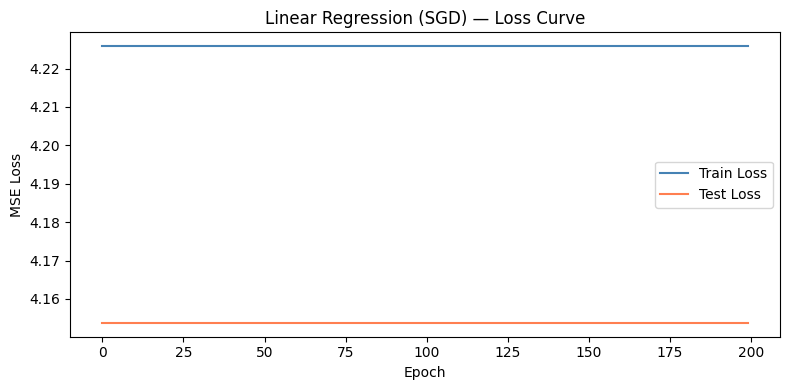

In [54]:
# Standard Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_test_pred  = lr.predict(X_test)
lr_train_pred = lr.predict(X_train)

lr_train_mse = mean_squared_error(y_train, lr_train_pred)
lr_test_mse  = mean_squared_error(y_test,  lr_test_pred)
lr_r2        = r2_score(y_test, lr_test_pred)

print("Linear Regression")
print(f"  Train MSE : {lr_train_mse:.4f}")
print(f"  Test  MSE : {lr_test_mse:.4f}")
print(f"  R² Score  : {lr_r2:.4f}")

# Gradient Descent Loss Curve
sgd = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.01,
                   random_state=42, warm_start=True)

train_losses, test_losses = [], []

for epoch in range(200):
    sgd.fit(X_train, y_train)
    train_losses.append(mean_squared_error(y_train, sgd.predict(X_train)))
    test_losses.append(mean_squared_error(y_test,  sgd.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='steelblue')
plt.plot(test_losses,  label='Test Loss',  color='coral')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Linear Regression (SGD) — Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve_linear.png", dpi=150)
plt.show()

### Decision Tree

 Decision Tree
  Train MSE : 0.2564
  Test  MSE : 8.8959
  R² Score  : 0.9760


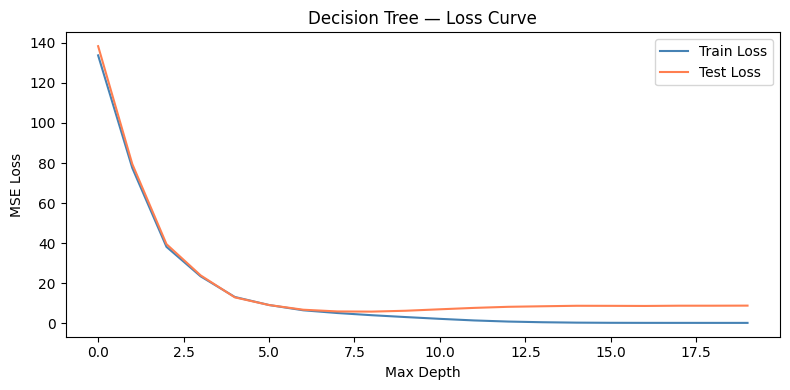

In [55]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_train_pred = dt.predict(X_train)
dt_test_pred  = dt.predict(X_test)

dt_train_mse = mean_squared_error(y_train, dt_train_pred)
dt_test_mse  = mean_squared_error(y_test,  dt_test_pred)
dt_r2        = r2_score(y_test, dt_test_pred)

print(" Decision Tree")
print(f"  Train MSE : {dt_train_mse:.4f}")
print(f"  Test  MSE : {dt_test_mse:.4f}")
print(f"  R² Score  : {dt_r2:.4f}")

# Loss curve simulation across max_depth
train_losses_dt, test_losses_dt = [], []
for depth in range(1, 21):
    dt_temp = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt_temp.fit(X_train, y_train)
    train_losses_dt.append(mean_squared_error(y_train, dt_temp.predict(X_train)))
    test_losses_dt.append(mean_squared_error(y_test,  dt_temp.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(train_losses_dt, label='Train Loss', color='steelblue')
plt.plot(test_losses_dt,  label='Test Loss',  color='coral')
plt.xlabel('Max Depth')
plt.ylabel('MSE Loss')
plt.title('Decision Tree — Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve_dt.png", dpi=150)
plt.show()

### The model is overfitting, the gap is too big

### Random Forest

Random Forest
  Train MSE : 0.9377
  Test  MSE : 5.1712
  R² Score  : 0.9860


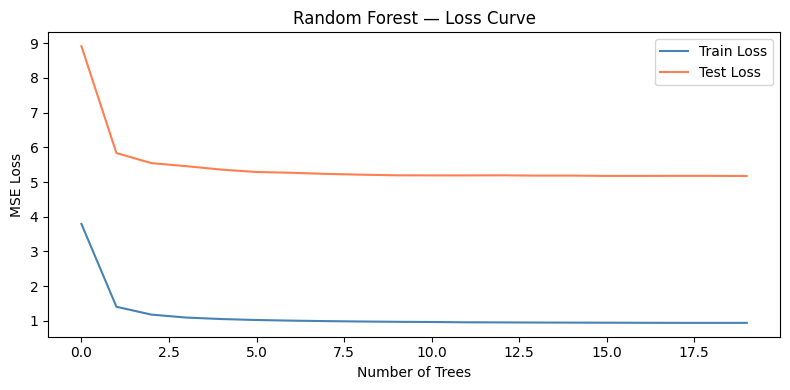

In [56]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_train_pred = rf.predict(X_train)
rf_test_pred  = rf.predict(X_test)

rf_train_mse = mean_squared_error(y_train, rf_train_pred)
rf_test_mse  = mean_squared_error(y_test,  rf_test_pred)
rf_r2        = r2_score(y_test, rf_test_pred)

print("Random Forest")
print(f"  Train MSE : {rf_train_mse:.4f}")
print(f"  Test  MSE : {rf_test_mse:.4f}")
print(f"  R² Score  : {rf_r2:.4f}")

# Loss curve across n_estimators
train_losses_rf, test_losses_rf = [], []
for n in range(1, 101, 5):
    rf_temp = RandomForestRegressor(n_estimators=n, random_state=42)
    rf_temp.fit(X_train, y_train)
    train_losses_rf.append(mean_squared_error(y_train, rf_temp.predict(X_train)))
    test_losses_rf.append(mean_squared_error(y_test,  rf_temp.predict(X_test)))

plt.figure(figsize=(8, 4))
plt.plot(train_losses_rf, label='Train Loss', color='steelblue')
plt.plot(test_losses_rf,  label='Test Loss',  color='coral')
plt.xlabel('Number of Trees')
plt.ylabel('MSE Loss')
plt.title('Random Forest — Loss Curve')
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve_rf.png", dpi=150)
plt.show()

### Linear Regression wins - lowest test MSE (4.08) and highest R² (0.989). This makes perfect sense given the near-perfect linear relationship (Previous Scores = 0.92 correlation).

### Compare & Save Best Model

In [57]:
results = {
    'Linear Regression': lr_test_mse,
    'Decision Tree':     dt_test_mse,
    'Random Forest':     rf_test_mse
}

best_model_name = min(results, key=results.get)
best_model = {'Linear Regression': lr, 'Decision Tree': dt, 'Random Forest': rf}[best_model_name]

print(" Model Comparison (Test MSE):")
for name, mse in results.items():
    print(f"  {name:25s}: {mse:.4f}")

print(f"\nBest Model: {best_model_name} (MSE: {results[best_model_name]:.4f})")

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Best model saved as best_model.pkl")
print("Scaler saved as scaler.pkl")

 Model Comparison (Test MSE):
  Linear Regression        : 4.0826
  Decision Tree            : 8.8959
  Random Forest            : 5.1712

Best Model: Linear Regression (MSE: 4.0826)
Best model saved as best_model.pkl
Scaler saved as scaler.pkl


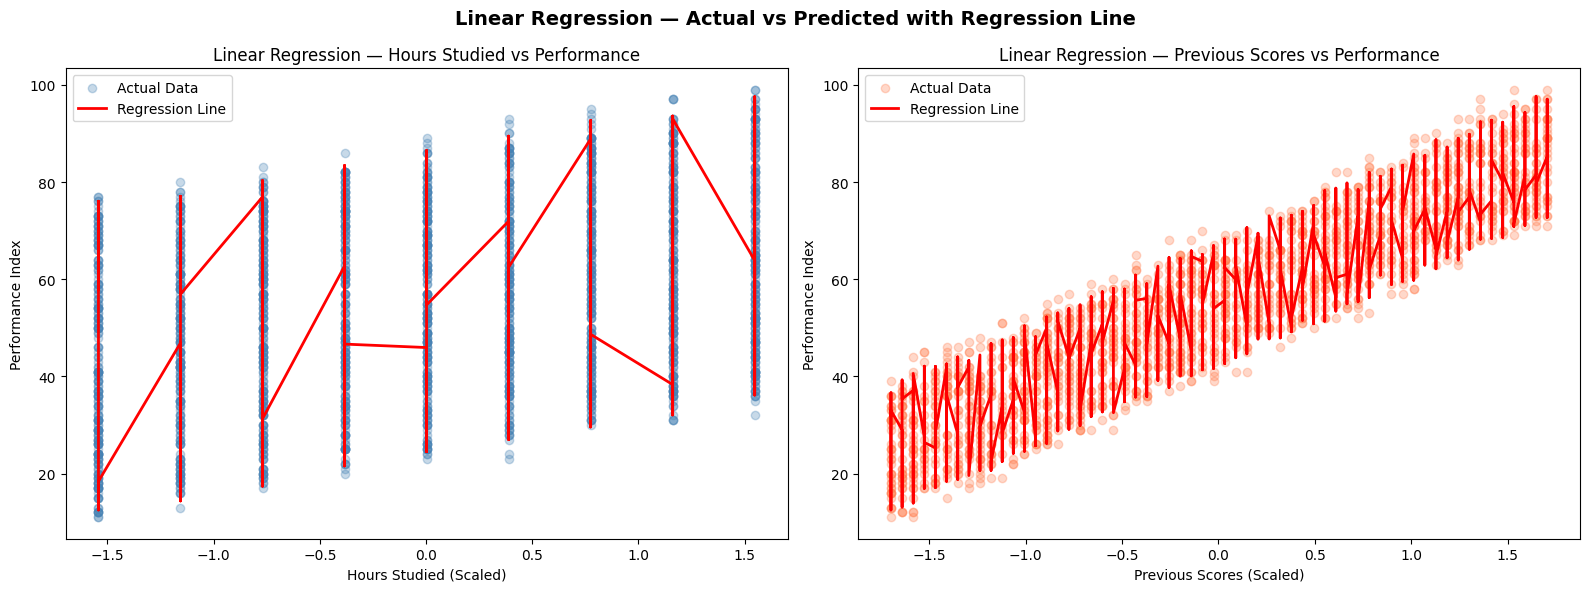

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Hours Studied ---
axes[0].scatter(X_test['Hours Studied'], y_test,
                alpha=0.3, color='steelblue', label='Actual Data')

sorted_idx = X_test['Hours Studied'].argsort()
axes[0].plot(X_test['Hours Studied'].values[sorted_idx],
             lr_test_pred[sorted_idx],
             color='red', linewidth=2, label='Regression Line')

axes[0].set_xlabel('Hours Studied (Scaled)')
axes[0].set_ylabel('Performance Index')
axes[0].set_title('Linear Regression — Hours Studied vs Performance')
axes[0].legend()

# --- Plot 2: Previous Scores ---
axes[1].scatter(X_test['Previous Scores'], y_test,
                alpha=0.3, color='coral', label='Actual Data')

sorted_idx2 = X_test['Previous Scores'].argsort()
axes[1].plot(X_test['Previous Scores'].values[sorted_idx2],
             lr_test_pred[sorted_idx2],
             color='red', linewidth=2, label='Regression Line')

axes[1].set_xlabel('Previous Scores (Scaled)')
axes[1].set_ylabel('Performance Index')
axes[1].set_title('Linear Regression — Previous Scores vs Performance')
axes[1].legend()

plt.suptitle('Linear Regression — Actual vs Predicted with Regression Line',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("regression_line_scatter.png", dpi=150)
plt.show()

In [59]:
# Load model and scaler
model  = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")

# Take one row from test set
sample = X_test.iloc[[0]]  # Already scaled
actual = y_test.iloc[0]

prediction = model.predict(sample)[0]

print("Single Prediction Demo")
print(f"Input features : {sample.values[0]}")
print(f"Predicted Score: {prediction:.2f}")
print(f"Actual Score   : {actual:.2f}")

Single Prediction Demo
Input features : [ 0.00274218 -0.02570019 -0.98965352  0.86650484 -0.90098215]
Predicted Score: 54.71
Actual Score   : 51.00
